In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [21]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [22]:
x = df['Hours Studied']
y = df['Grade on Exam']

x_mean = x.mean()
y_mean = y.mean()

In [23]:
x_mean

np.float64(4.8)

In [24]:
y_mean

np.float64(77.8)

In [25]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope(β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope(β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


In [26]:
X = 0

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')


0 hours of work results 55.03550295857988


In [27]:
beta1 = 1.5

In [28]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
3,5,77
2,5,82
8,6,84
5,7,84
7,8,94
1,9,98


In [29]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours

print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 61.04


#### Installing Scikit Learn package

In [30]:
# Importing LinearRegression
from sklearn.linear_model import LinearRegression

ads = pd.read_csv('../data/regression//advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [31]:
X = ads[['tv']]
y = ads['sales']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
model.intercept_

np.float64(-132.49250561831286)

In [33]:
model.predict(X)

array([ 56851.73298719,  46167.19070729, 145889.58531972, ...,
       156574.12759962, 252735.00811874, 149451.09941302], shape=(4546,))

In [34]:
def predict(n):
    y_hat = model.intercept_ + model.copy_*X.iloc[n]
    return y_hat

In [35]:
channels = ['tv', 'radio', 'social_media']

# import statsmodels.api as sm

# X = sm.add_constant(X)    # IMPORTANT: add intercept
# model = sm.OLS(y, X).fit()

# model.rsquared
from utils import rsquered
for channel in channels:
    X = ads[[channel]]
    y = ads['sales']

    model = LinearRegression()
    model.fit(X, y) 

    y_hat = model.predict(X)

    r2 = 1 - rsquered(y, y_hat)
    rmse = np.sqrt(np.mean(y - y_hat)**2)

    print(f'Intercept {channel}: {model.intercept_:2f}')
    print(f'Coef {channel}: {model.coef_[0]:f}')
    print(f'R_Squared {channel}: {r2}')
    print(f'RMSE {channel}: {rmse}')
    print(100*'-')

Intercept tv: -132.492506
Coef tv: 3.561514
R_Squared tv: 0.0010050154760091745
RMSE tv: 2.2823395419765872e-11
----------------------------------------------------------------------------------------------------
Intercept radio: 40586.800679
Coef radio: 8.361628
R_Squared radio: 0.24546834878047163
RMSE radio: 1.4545513153915305e-11
----------------------------------------------------------------------------------------------------
Intercept social_media: 118672.571739
Coef social_media: 22.187863
R_Squared social_media: 0.7218002719020451
RMSE social_media: 5.121659561237783e-12
----------------------------------------------------------------------------------------------------


In [36]:
corr = ads[['tv', 'radio', 'social_media', 'sales']].corr().round(3)
corr

,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


In [37]:
import plotly.express as px

fig = px.imshow(corr)
fig.show()

In [38]:
# Compute correlation
corr = ads[["tv", "radio", "social_media", "sales"]].corr().round(3)

# Plot
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
)

# Improve layout
fig.update_layout(
    title="Correlation Matrix",
    xaxis_title="",
    yaxis_title="",
)

fig.show()

#### Multiple Linear Regression

In [39]:
X = ads[['tv','radio','social_media']]
y = ads['sales']

In [40]:
model = LinearRegression()
model.fit(X,y)

y_hat = model.predict(X)

y_hat

array([ 56855.51571432,  46154.7257576 , 145882.77851125, ...,
       156565.78405758, 252748.49571829, 149455.61837128], shape=(4546,))

In [58]:
from sklearn.metrics import r2_score, mean_squared_error
r2_sklearn = r2_score(y_true = y, y_pred=y_hat)
rmse_sklearn = root_mean_squared_error(y_true = y, y_pred = y_hat)

In [59]:
print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")

R-squared (sklearn): 0.9990
RMSE (sklearn): 2948.5350


In [61]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)

y_hat_multi_num = multi_num_model.predict(X_multi_num)

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_r2 = r2_score(y_sales, y_hat_multi_num)
multi_num_rmse = np.sqrt(mean_squared_error(y_sales, y_hat_multi_num))


print(f"R-squared: {multi_num_r2:.4f}")
print(f"RMSE: {multi_num_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.54


In [63]:
multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


In [64]:
multi_num_model.intercept_

np.float64(-133.96296784223523)

#### Multiple regression with the influencer variable

In [65]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)

y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),

    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = 1 - np.sum((y_sales - y_hat_multi)**2) / np.sum((y_sales - y_sales.mean())**2)
multi_rmse = np.sqrt(np.mean((y_sales - y_hat_multi)**2))

multi_results
print(f"R-Squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")

R-Squared: 0.9990
RMSE: 2948.31


In [66]:
X_multi

,tv,radio,social_media,influencer_Macro,influencer_Micro,influencer_Nano
0,16000.0,6566.23,2907.98,0,0,0
1,13000.0,9237.76,2409.57,0,0,0
2,41000.0,15886.45,2913.41,0,0,0
3,83000.0,30020.03,6922.30,0,0,0
4,15000.0,8437.41,1406.00,0,1,0
...,...,...,...,...,...,...
4541,26000.0,4472.36,717.09,0,1,0
4542,71000.0,20610.69,6545.57,0,0,1
4543,44000.0,19800.07,5096.19,0,1,0
4544,71000.0,17534.64,1940.87,1,0,0


#### Example 2 | Price → Demand

In [ ]:
np.random.seed(42)

price = np.linspace(10,  100, 40)
demand = 1200 - 8 * price + np.random.normal(0, 35, size=40)

X_price = price.reshape(-1, 1)
6
price_model = LinearRegression()
price_model.fit(X_price, demand)

demand_pred = price_model.predict(X_price)

price_r2 = 1 - np.sum((demand - demand_pred)**2) / np.sum((demand - demand.mean())**2)
price_rmse = np.sqrt(np.mean((demand - demand_pred)**2))

print(f"Intercept: {price_model.intercept_:.4f}")
print(f"Slope: {price_model.coef_[0]:.4f}")
print(f"R-Squared: {price_r2:.4f}")
print(f"RMSE: {price_rmse:.4f}")

Intercept: 1209.3747
Slope: -8.3096
R-Squared: 0.9797
RMSE: 31.8794


#### Example 3 | Customer Age → Revenue

In [68]:
np.random.seed(7)

age = np.random.randint(18, 66, size=50)
revenue = 18 + 2.4 * age + np.random.normal(0, 12, size=50)

X_age = age.reshape(-1, 1)

age_model = LinearRegression()
age_model.fit(X_age, revenue)

revenue_pred = age_model.predict(X_age)

age_r2 = 1 - np.sum((revenue - revenue_pred)**2) / np.sum((revenue - revenue.mean())**2)
age_rmse = np.sqrt(np.mean((revenue - revenue_pred)**2))

print(f"Intercept: {age_model.intercept_:.4f}")
print(f"Slope: {age_model.coef_[0]:.4f}")
print(f"R-squared: {age_r2:.4f}")
print(f"RMSE: {age_rmse:.4f}")

Intercept: 18.6013
Slope: 2.3835
R-squared: 0.8834
RMSE: 12.8626


#### Time Series

In [72]:
import pandas as pd
from os.path import join
PATH = '../data/regression/time_series'

In [75]:
ts = pd.read_csv(join(PATH, 'gold_prices_2022_2023.csv'), parse_dates=['Date'])
print(ts.shape)
ts.head()

(250, 5)


,Date,Open,High,Low,Close
0,2023-04-21,"2,016.10","2,016.80","1,982.30","1,990.50"
1,2023-04-20,"2,007.70","2,024.20","2,002.20","2,019.10"
2,2023-04-19,"2,017.90","2,020.30","1,980.90","2,007.30"
3,2023-04-18,"2,007.90","2,024.60","2,003.30","2,019.70"
4,2023-04-17,"2,014.10","2,028.00","1,993.40","2,007.00"


In [77]:
import glob
import os
file_paths = glob.glob(join(PATH, "*.csv"))
file_paths

['../data/regression/time_series\\gold_prices_2022_2023.csv',
 '../data/regression/time_series\\gold_prices_2023_2024.csv',
 '../data/regression/time_series\\gold_prices_2024_2025.csv',
 '../data/regression/time_series\\gold_prices_2025_2026.csv']

In [78]:
file_names = [os.path.basename(file) for file in file_paths]
file_names

['gold_prices_2022_2023.csv',
 'gold_prices_2023_2024.csv',
 'gold_prices_2024_2025.csv',
 'gold_prices_2025_2026.csv']

In [ ]:
dataframes = [pd.read_csv(file, parse_dates=['Date']) for file in file_paths]
ts_combined = pd.concat(dataframes, ignore_index=True)
print(ts_combined.shape)
ts_combined.head()

(1008, 5)


,Date,Open,High,Low,Close
0,2023-04-21,"2,016.10","2,016.80","1,982.30","1,990.50"
1,2023-04-20,"2,007.70","2,024.20","2,002.20","2,019.10"
2,2023-04-19,"2,017.90","2,020.30","1,980.90","2,007.30"
3,2023-04-18,"2,007.90","2,024.60","2,003.30","2,019.70"
4,2023-04-17,"2,014.10","2,028.00","1,993.40","2,007.00"


In [80]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [ ]:
ts_combined["Close"] = (
    ts_combined["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined["Close"] = pd.to_numeric(ts_combined["Close"], errors="coerce")

#### Visualization

In [83]:
ts_combined = ts_combined.sort_values(by='Date')

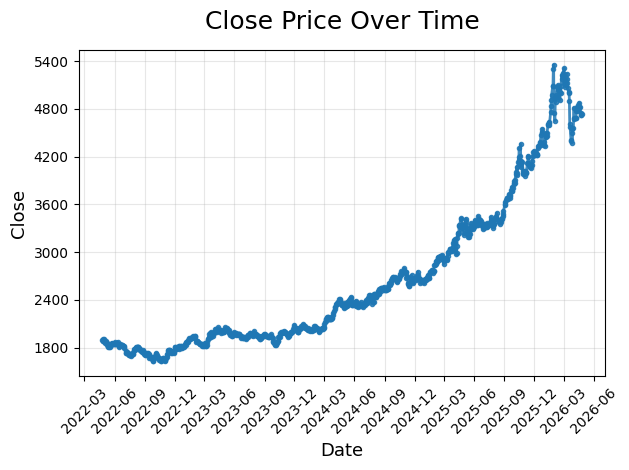

In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

plt.plot(
    ts_combined["Date"],
    ts_combined["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
ts_combined["time_index"] = np.arange(1, len(ts_combined) + 1)

X_time = ts_combined[["time_index"]]
y_time = ts_combined["Close"]

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse = np.sqrt(mean_squared_error(y_time, trend_pred))

print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1152.71
Slope: 2.9477
R-squared: 0.8247
RMSE: 395.4914


#### ARIMA - փորձում է կանխատեսել ապագա արժեքները՝ օգտագործելով անցյալը

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

ts_arima = ts_combined.set_index("Date").asfreq("B") # .asfreq("B") : Business Day frequency| միայն աշխատանքային օրեր

arima_model = ARIMA(ts_arima["Close"], order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=3)
arima_forecast

2026-04-27    4742.197623
2026-04-28    4742.974112
2026-04-29    4743.438758
Freq: B, Name: predicted_mean, dtype: float64

#### Prophet - Prophet is a forecasting package for Python and R developed by Facebook.


In [91]:
from prophet import Prophet

df_prophet = ts_combined.rename(columns={"Date": "ds", "Close": "y"})

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=3, freq="B")

forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

00:37:38 - cmdstanpy - INFO - Chain [1] start processing
00:37:39 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1008,2026-04-27,5128.463674,4992.470811,5262.384782
1009,2026-04-28,5134.277446,5000.028705,5265.073928
1010,2026-04-29,5142.044037,5018.793496,5272.828482


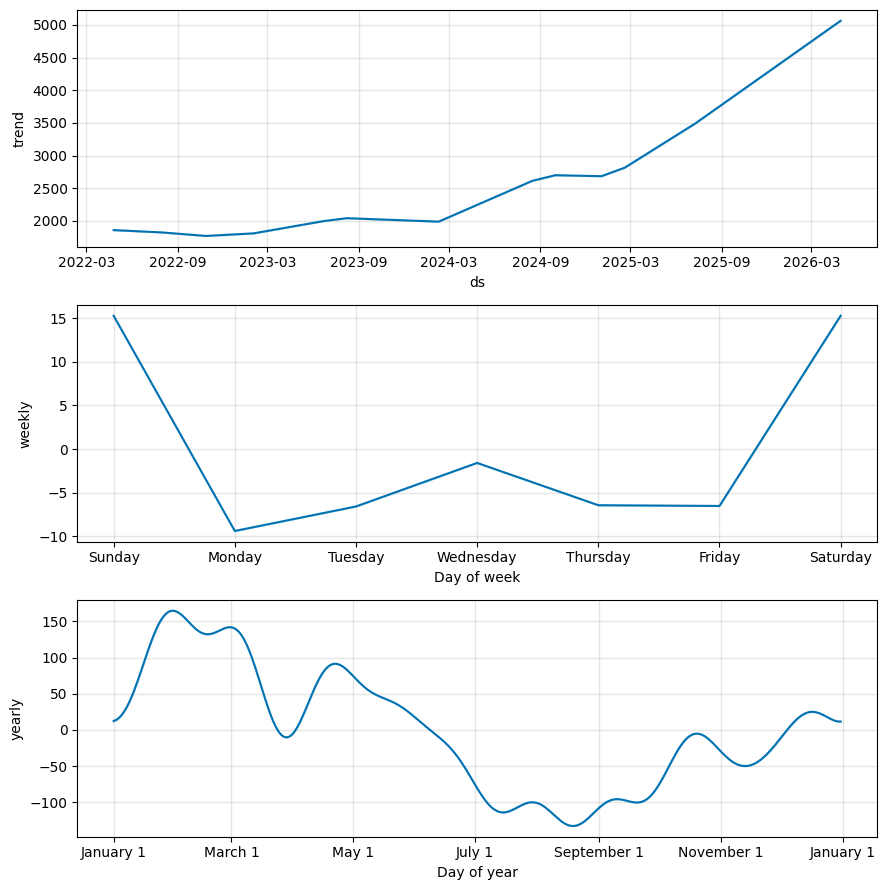

In [92]:
prophet_model.plot_components(forecast)
plt.show()